In [79]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [80]:
from handcalcs import *
from handcalcs import render
import handcalcs

In [81]:
def trigger (sig , thresh= None, transition= "rise", marginI = 20):
    arr=[0]
    if thresh is None: 
        thresh = (sig.max()+sig.min())/2
    for i in range(1, len(sig)):
        if transition =="rise":
            if sig[i-1] <thresh and sig[i] >= thresh and i > arr[-1]+marginI:
                arr.append(i)
        elif sig[i-1] >thresh and sig[i] <= thresh and i > arr[-1]+marginI:
            arr.append(i)
    return arr[1:]


In [82]:
# Initialization 
bl= '#1520c0' # blue 
rd= '#C62828' # red
fig_counter=1

In [83]:
# CONFIGURATIONS
#help(handcalcs.set_option)
handcalcs.set_option("latex_block_start", "$")
handcalcs.set_option("latex_block_end", "$")
handcalcs.set_option("math_environment_end", "aligned")
handcalcs.set_option("use_scientific_notation",True)

# TEST

### LR

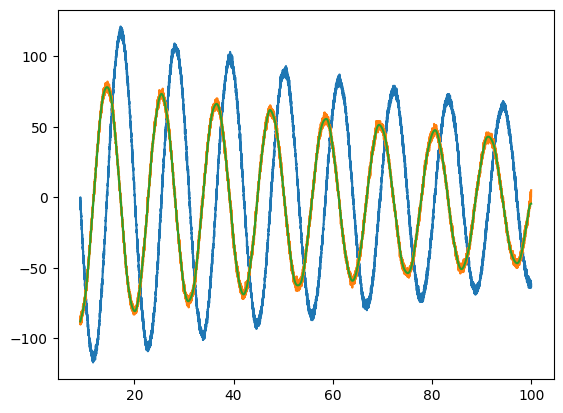

In [7]:
# Lm
# df = pd.read_csv("05_LLC_resonance/2026-01-12_17-37-55-165.csv")
# Lr
df = pd.read_csv("05_LLC_resonance/2026-01-12_17-30-26-003.csv")


Ts= df.Ts.iloc[0]

vc = df.CH1.values #-v0
ic = df.CH2.values #-v0
idx= trigger(vc, transition='fall', thresh=0)[0]

import numpy as np
from scipy import signal
fs = 1 / Ts          # sampling frequency
fc = 1e6          # cutoff frequency (Hz)
order = 4
# design filter
sos = signal.butter(order, fc, btype='low', fs=fs, output='sos')
# zero-phase filtering
ic2= signal.sosfiltfilt(sos, ic)



vc= vc[idx:]
ic= ic[idx:]
ic2= ic2[idx:]
time = df.time.values[idx:]
plt.plot(time*1e6, vc, label="Vc: Measurement (CH1)"   )
plt.plot(time*1e6, 10*ic, label="ic: Measurement (CH2)"   )
plt.plot(time*1e6, 10*ic2, label="ic: 5 MHz LP filter, zero phase"   )


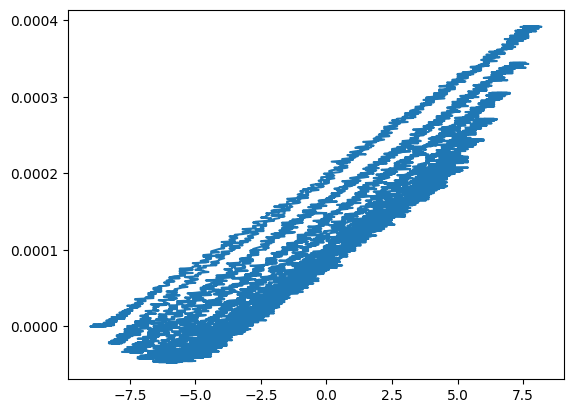

In [8]:
integV= -np.cumsum(vc)*Ts
plt.plot(ic, integV, label="ic vs integ(Vc)")

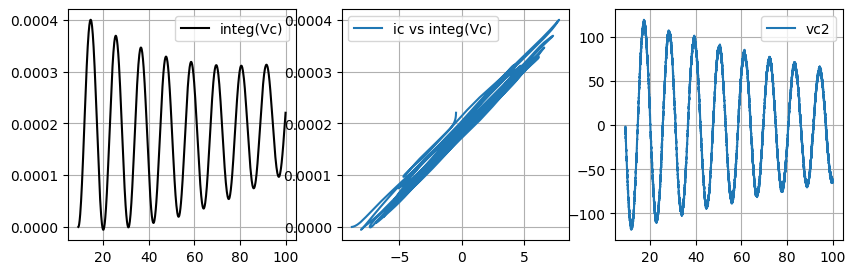

In [9]:
fig, axs = plt.subplots(1,3,figsize=(10, 3))
# vc2=vc+0.15*np.mean(vc) # Lm
vc2=vc-1.5 # Lr
integV= -np.cumsum(vc2)*Ts
axs[0].plot(time*1e6, integV, label="integ(Vc)", c="k")
axs[0].grid()
axs[0].legend()
axs[1].plot(ic2, integV, label="ic vs integ(Vc)")
axs[1].grid()
axs[1].legend()

axs[2].plot(time*1e6, vc2, label="vc2")
axs[2].grid()
axs[2].legend()


### LM 

In [84]:
%%render 3 sci_not
A_e_mm = 534.2 # mm2
A_e = A_e_mm * 1e-6 # m2
l_e_mm = 121.2  # mm
l_e = l_e_mm * 1e-3 # m
AL_nom = 9600 # nH/N2

Ve_mm = 67745 #mm3
Ve = Ve_mm * 1e-9 # m3

<IPython.core.display.Latex object>

Oscilloscope channel configuration (see setup above):

*   CH1 = Isolated ×100 probe measuring capacitor voltage
*   CH2 = Current probe
*   CH3 = Isolated shunt‑based current measurement (50 Ω)
*   CH4 = Vdd (composite Vout: drain‑high minus drain‑low, ×10, non‑isolated)


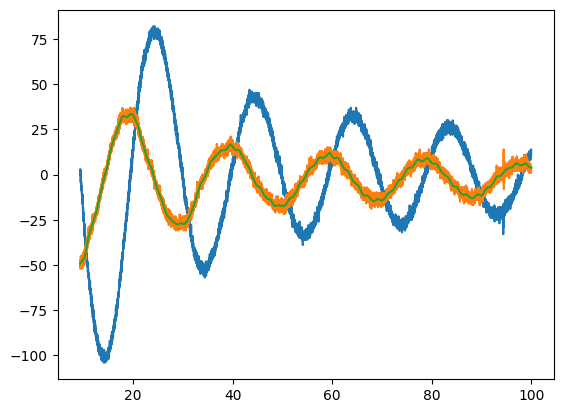

In [201]:
# Lm
df = pd.read_csv("05_LLC_resonance/2026-01-12_17-37-55-165.csv")
# Lr
#df = pd.read_csv("05_LLC_resonance/2026-01-12_17-30-26-003.csv")


Ts= df.Ts.iloc[0]

vc = df.CH1.values #-v0
ic = df.CH2.values #-v0
idx= trigger(vc, transition='fall', thresh=0)[0]

import numpy as np
from scipy import signal
fs = 1 / Ts          # sampling frequency
fc = 1e6          # cutoff frequency (Hz)
order = 4
# design filter
sos = signal.butter(order, fc, btype='low', fs=fs, output='sos')
# zero-phase filtering
ic2= signal.sosfiltfilt(sos, ic)



vc= vc[idx:]
ic= ic[idx:]
ic2= ic2[idx:]
time = df.time.values[idx:]
plt.plot(time*1e6, vc, label="Vc: Measurement (CH1)"   )
plt.plot(time*1e6, 10*ic, label="ic: Measurement (CH2)"   )
plt.plot(time*1e6, 10*ic2, label="ic: 5 MHz LP filter, zero phase"   )


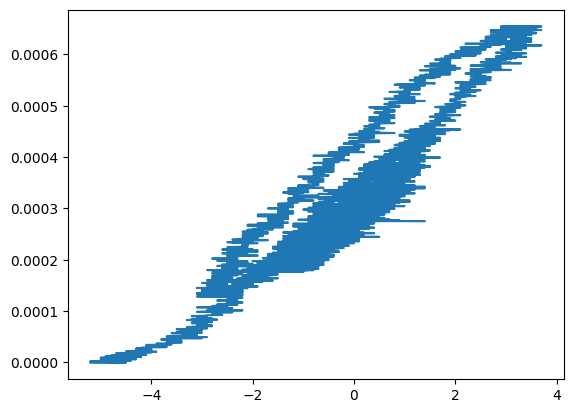

In [202]:
integV= -np.cumsum(vc)*Ts
plt.plot(ic, integV, label="ic vs integ(Vc)")

In [203]:
# v = N * dflux / dt 
# flux = integral (v, t)/N
# B = flux / Ae
N= 4

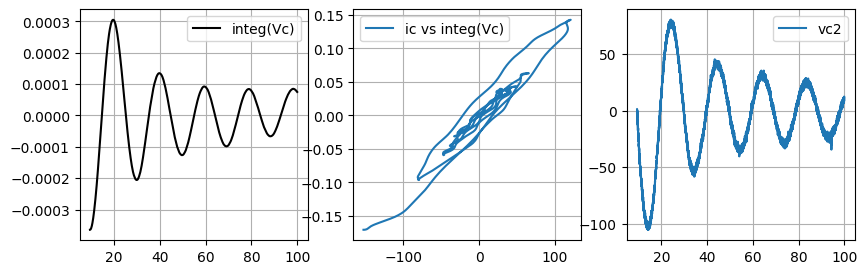

In [204]:
fig, axs = plt.subplots(1,3,figsize=(10, 3))
# vc2=vc+0.15*np.mean(vc) # Lm
vc2=vc-1.5 # Lr
integV= -np.cumsum(vc2)*Ts
integV=integV- np.mean(integV)
flux = integV/N
B = flux /A_e
H = N*ic2/l_e
#H = N*ic/l_e
axs[0].plot(time*1e6, integV, label="integ(Vc)", c="k")
axs[0].grid()
axs[0].legend()
H0=-10
B0= 0
axs[1].plot(H-H0, B-B0, label="ic vs integ(Vc)")
axs[1].grid()
axs[1].legend()

axs[2].plot(time*1e6, vc2, label="vc2")
axs[2].grid()
axs[2].legend()


In [205]:
import plotly.express as px
import plotly.graph_objects as go       
fig = px.line(x=H, y=B, labels={"x":"H (A/m)", "y":"B (T)"}, title="B-H curve")
fig.update_layout(width = 600, height=400   )
fig.show()

In [206]:
import plotly.express as px
import plotly.graph_objects as go       
import numpy as np

# Créer un array avec les indices
indices = np.arange(len(H))

fig = px.line(
    x=H, 
    y=B, 
    labels={"x":"H (A/m)", "y":"B (T)"}, 
    title="B-H curve",
    hover_data={'index': indices}  # Ajouter l'index aux données de survol
)
fig.update_layout(width=500, height=400)
fig.show()

In [207]:
import plotly.express as px
import plotly.graph_objects as go       
import numpy as np

# Créer un array avec les indices
indices = np.arange(len(H))
i_delay= 100
fig = px.line(x=H[i_delay:], y=B[:-i_delay], labels={"x":"H (A/m)", "y":"B (T)"}, title="B-H curve",
    hover_data={'index': indices[i_delay:]}  # Ajouter l'index aux données de survol
)
fig.update_layout(width=500, height=400)
fig.show()

In [208]:
import plotly.express as px
import plotly.graph_objects as go       
import numpy as np

# Créer un array avec les indices
indices = np.arange(len(H))
i_delay= 30
fig = px.line(x=H[:-i_delay], y=B[i_delay:], labels={"x":"H (A/m)", "y":"B (T)"}, title="B-H curve",
    hover_data={'index': indices[i_delay:]}  # Ajouter l'index aux données de survol
)
fig.update_layout(width=500, height=400)
fig.show()

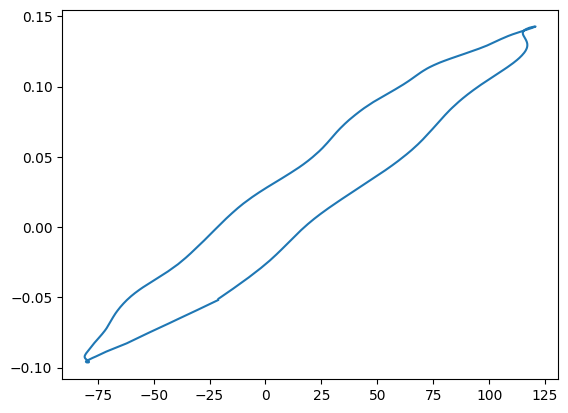

In [209]:
i0=414
i1= 2367

H_=H-H0
B_= B-B0
H2= H_[i0:i1]
B2= B_[i0:i1]
#plt.plot(H_, B_, label="ic vs integ(Vc)")
plt.plot(H2, B2, label="ic vs integ(Vc)")


In [210]:
px.line(x=H2, y=B2)

In [211]:
import plotly.express as px
import plotly.graph_objects as go       
import numpy as np

# Créer un array avec les indices
indices = np.arange(len(H2))

fig = px.scatter(
    x=H2, 
    y=B2, 
    labels={"x":"H (A/m)", "y":"B (T)"}, 
    title="B-H curve",
    hover_data={'index': indices}  # Ajouter l'index aux données de survol
)
fig.update_layout(width=500, height=400)
fig.show()

In [212]:
# Calcul de l'aire de la boucle B-H
area = 0.5 * abs(sum(H2[i]*B2[i+1] - H2[i+1]*B2[i] for i in range(-1, len(H2)-1)))
print(f"Aire de la boucle B-H: {area:.6f} J/m³")

Aire de la boucle B-H: 8.032660 J/m³


In [213]:
import numpy as np
area = 0.5 * abs(np.sum(H2[:-1]*B2[1:] - H2[1:]*B2[:-1]))
print(f"Aire de la boucle B-H: {area:.6f} J/m³")

Aire de la boucle B-H: 8.036249 J/m³


In [214]:
import numpy as np
from matplotlib.path import Path
points = np.column_stack((H2, B2))
path = Path(points)
# Calculer avec la formule du shoelace via matplotlib
area = 0.5 * abs(sum((H2[i]*B2[i+1] - H2[i+1]*B2[i]) for i in range(-1, len(H2)-1)))
print(f"Aire de la boucle B-H: {area:.6f} J/m³")

Aire de la boucle B-H: 8.032660 J/m³


In [215]:
from scipy.spatial import ConvexHull
import numpy as np
points = np.column_stack((H2, B2))
hull = ConvexHull(points)
area = hull.volume  # En 2D, volume = area
print(f"Aire de la boucle B-H: {area:.6f} J/m³")

Aire de la boucle B-H: 8.744275 J/m³


In [216]:
area = np.abs(np.trapezoid(B2, H2 ))
print(f"Aire de la boucle B-H: {area:.6f} J/m³")
Freq = 100e3
Ecycle= area *Ve
print(f"Energie par cycle: {Ecycle:.6f} J")
P = Ecycle*Freq
print(f"Power loss: {P:.6f} W")



Aire de la boucle B-H: 8.018889 J/m³
Energie par cycle: 0.000543 J
Power loss: 54.323966 W


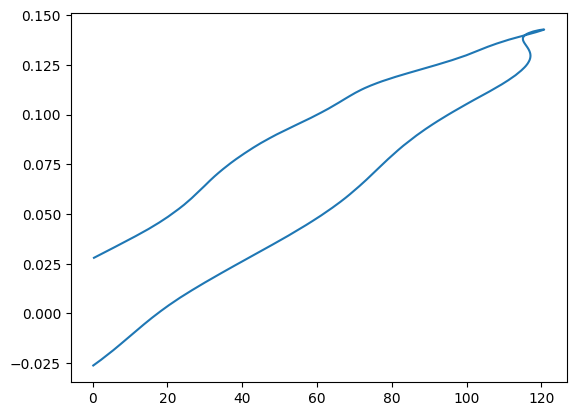

In [217]:

i0, i1= 52,1080

H3= H2[i0:i1]
B3= B2[i0:i1]
#plt.plot(H_, B_, label="ic vs integ(Vc)")
plt.plot(H3, B3, label="ic vs integ(Vc)")


In [218]:
area = 2*np.abs(np.trapezoid(B3, H3 ))
print(f"# Aire de la boucle B-H: {area:.6f} J/m³")
Freq = 100e3
Ecycle= area *Ve
print(f"# Energie par cycle: {Ecycle:.6f} J")
P = Ecycle*Freq
print(f"# Power loss: {P:.6f} W")

# Aire de la boucle B-H: 9.844337 J/m³
# Energie par cycle: 0.000667 J
# Power loss: 66.690461 W

# Aire de la boucle B-H: 9.844337 J/m³
# Energie par cycle: 0.000667 J
# Power loss: 66.690461 W


In [219]:
# datasheet 
# https://www.tdk-electronics.tdk.com/inf/80/db/fer/elp_102_20_38.pdf
# < 8.0 (100 mT, 100 kHz, 100 °C)
Pv = 8 # W/set

In [220]:
# Pertes ∝ B_peak^2.6 (approximation Steinmetz)
# Correction_B = (150/100)**2.6 ≈ 4.7×
# Pertes_corrigées = 8 × 4.7 ≈ 37.6 W

In [221]:
Freq=100e3

i_delay= 0 Area= 9.84433701386967
i_delay= 10 Area= 8.24900992151182
i_delay= 20 Area= 6.654976898243476
i_delay= 30 Area= 5.063639800760152
i_delay= 40 Area= 3.476545608293991
i_delay= 50 Area= 1.8951674015802382


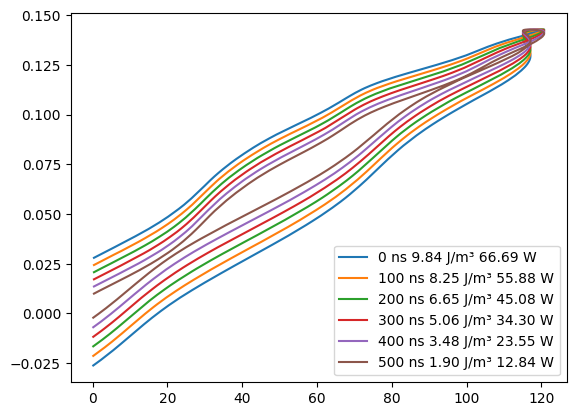

In [222]:
i0, i1= 0,1500

H3= H2[i0:i1]
B3= B2[i0:i1]

area0 = 2*np.trapezoid(B3, H3 )
#plt.plot(H3, B3, label="H3, B3 area = "+f"{area0:.6f} J/m³")
for i_delay in range(0, 60, 10):
    if i_delay==0:
        H4 = H3[:]
        B4 = B3[:]
    else:
        H4 = H3[:-i_delay]
        B4 = B3[i_delay:]

    mask= H4>=0
    H4= H4[mask]
    B4= B4[mask]
    area1 = 2*np.trapezoid(B4[::-1], H4[::-1] )
    Ecycle= area1*Ve

    P = Ecycle*Freq

    print("i_delay=", i_delay, "Area=", area1)


    plt.plot(H4, B4, label=f"{i_delay*Ts*1e9:.0f} ns {area1:.2f} J/m³ {P:.2f} W")
plt.legend()

# END TEST